In [91]:
import pandas as pd
import numpy as np
import math
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

mpl.rcParams['figure.figsize'] = (15.0, 6.0)
pd.set_option('display.max_columns', 30)

# Overview Of Datasets

The data is contained in three files:

* portfolio.json - containing offer ids and meta data about each offer (duration, type, etc.)
* profile.json - demographic data for each customer
* transcript.json - records for transactions, offers received, offers viewed, and offers completed

In [92]:
# Read in the json files
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'

portfolio = pd.read_json(DATA_DIR / 'portfolio.json', orient='records', lines=True)
profile = pd.read_json(DATA_DIR / 'profile.json', orient='records', lines=True)
transcript = pd.read_json(DATA_DIR / 'transcript.json', orient='records', lines=True)

## Offers

**portfolio.json**
* id (string) - offer id
* offer_type (string) - type of offer ie BOGO, discount, informational
* difficulty (int) - minimum required spend to complete an offer
* reward (int) - reward given for completing an offer
* duration (int) - time for offer to be open, in days
* channels (list of strings)

In [54]:
portfolio

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5


There has been 10 offers during the test period. 

In [55]:
portfolio.shape

(10, 6)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\2517676096.py:9: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  pd.Series(channel_counts).sort_values(ascending=False).plot(kind='bar')


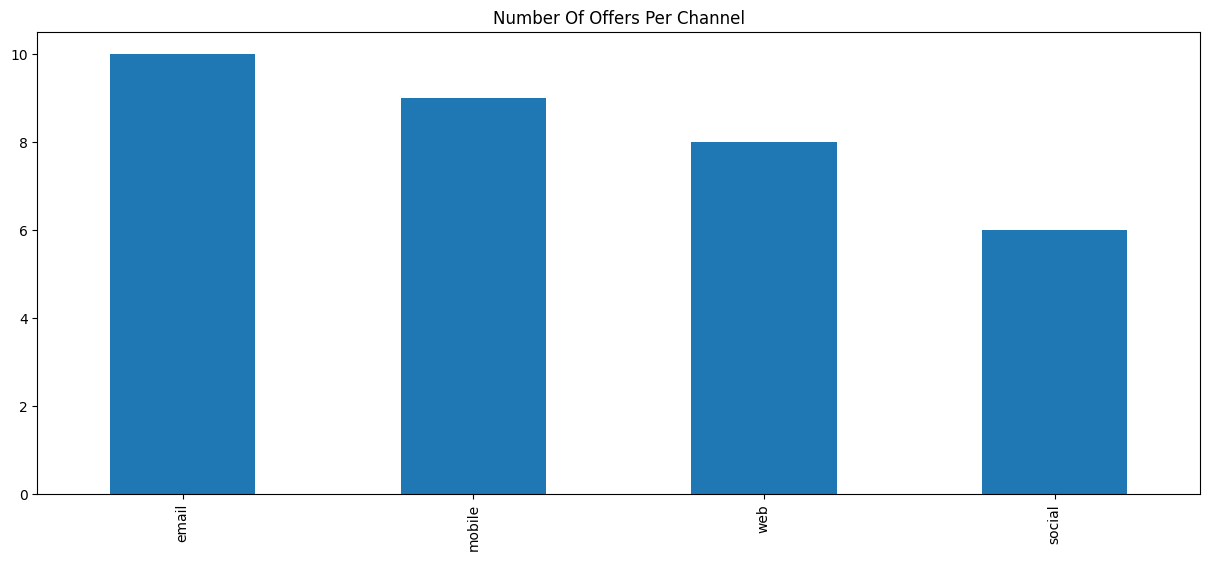

In [56]:
# Count channels
channels = portfolio.channels.explode().unique()
channel_counts = dict()
for channel in channels:
    channel_counts[channel] = portfolio.channels.str.contains(channel, regex=False).sum()
    
# Plot number of offers per channel
plt.title("Number Of Offers Per Channel")
pd.Series(channel_counts).sort_values(ascending=False).plot(kind='bar')
plt.show()

All offers are provided via email, so this feature will not provide any value.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\1286191603.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  portfolio.offer_type.value_counts().plot(kind='bar')


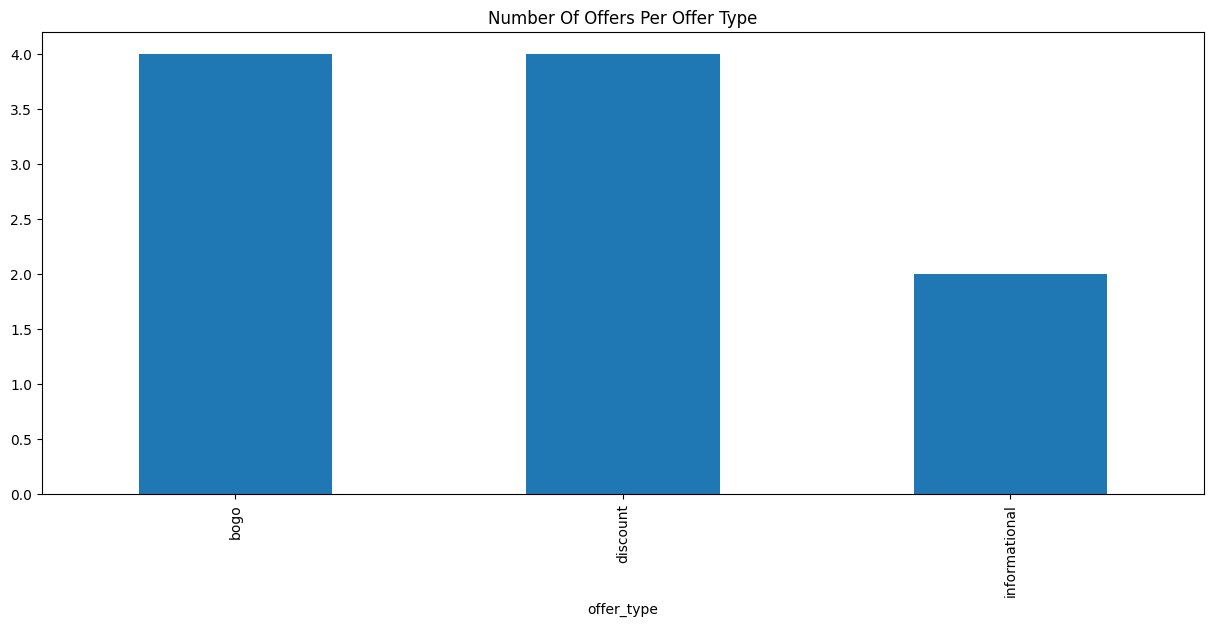

In [57]:
# Plot number of offers per offer type
plt.title("Number Of Offers Per Offer Type")
portfolio.offer_type.value_counts().plot(kind='bar')
plt.show()

Since this exercise focusses on the prediction of whether a customer will complete a reward, we will later discard the two informational offers.

## Customer

**profile.json**
* age (int) - age of the customer 
* became_member_on (int) - date when customer created an app account
* gender (str) - gender of the customer (note some entries contain 'O' for other rather than M or F)
* id (str) - customer id
* income (float) - customer's income

In [58]:
profile.head()

,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [59]:
profile.shape

(17000, 5)

In [60]:
profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  str    
 1   age               17000 non-null  int64  
 2   id                17000 non-null  str    
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 664.2 KB


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\3866655826.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  profile.gender.fillna('NULL').value_counts().plot(kind='bar')


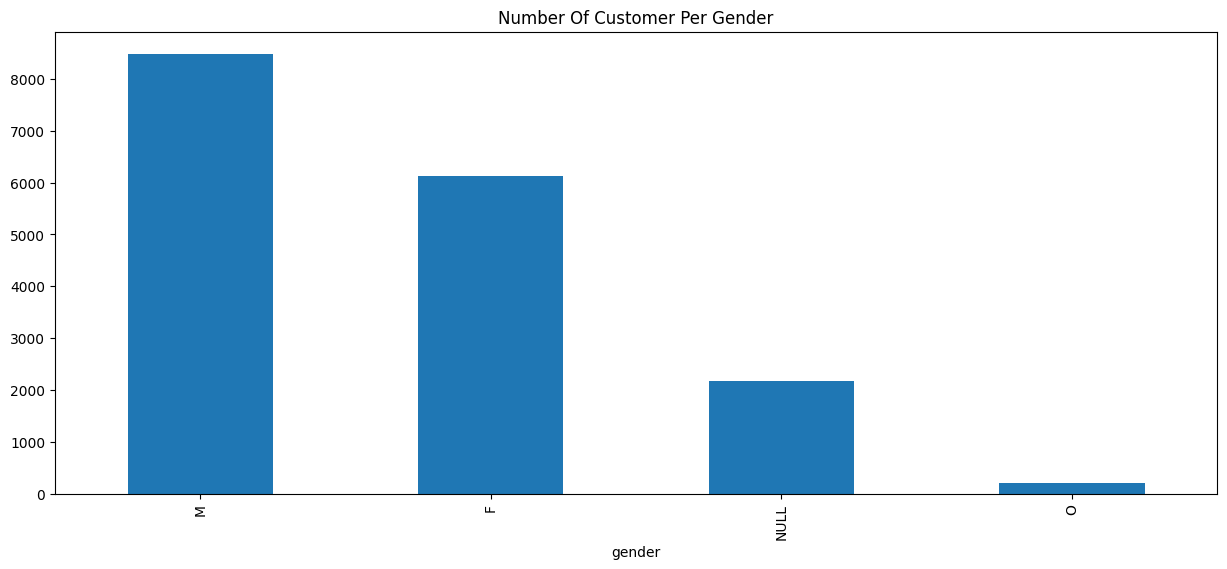

In [61]:
plt.title("Number Of Customer Per Gender")
profile.gender.fillna('NULL').value_counts().plot(kind='bar')
plt.show()

Most customers are male. There is fair amount of customer who do not report any information about gender.

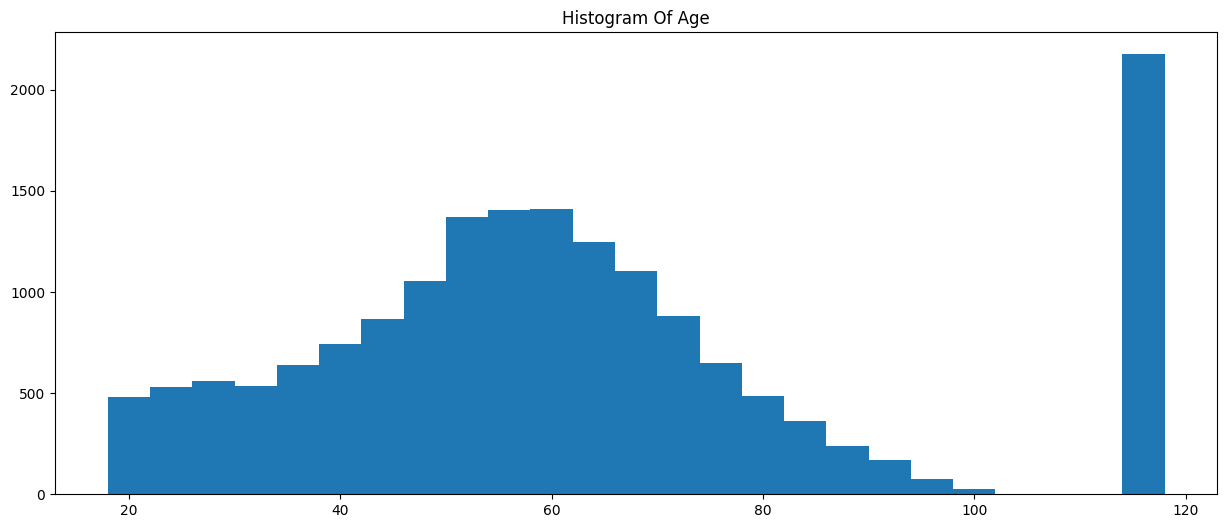

In [62]:
plt.title("Histogram Of Age")
profile.age.hist(bins=25, grid=False)
plt.show()

For the age column, the value 118 seems to indicate missing value. We will keep this in mind for our data processing pipeline.

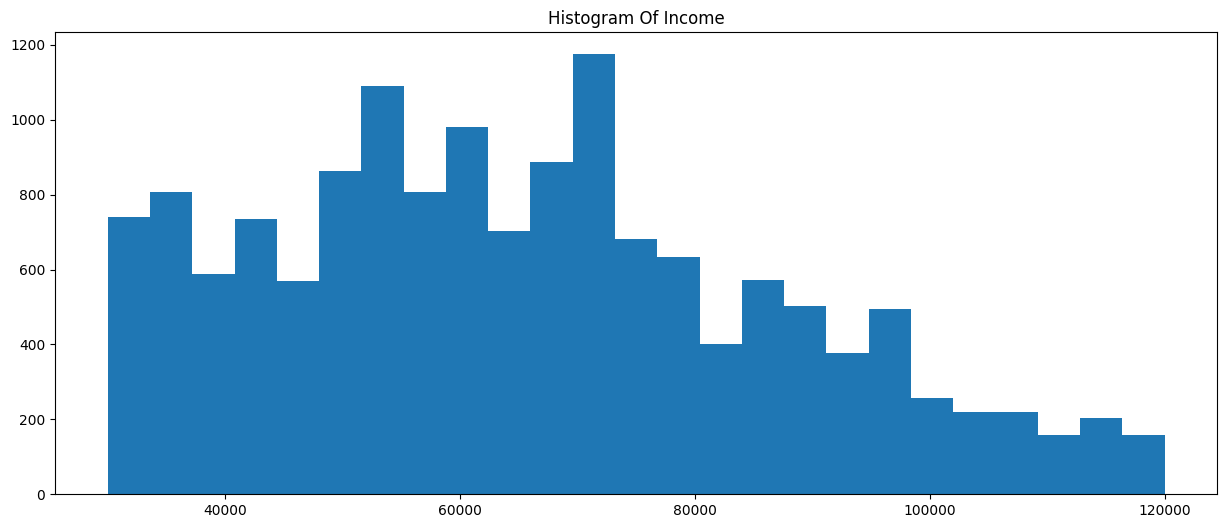

In [48]:
plt.title("Histogram Of Income")
profile.income.hist(bins=25, grid=False)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\1385595339.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  pd.to_datetime(profile.became_member_on, format='%Y%m%d').dt.year.value_counts().sort_index().plot(kind='bar')


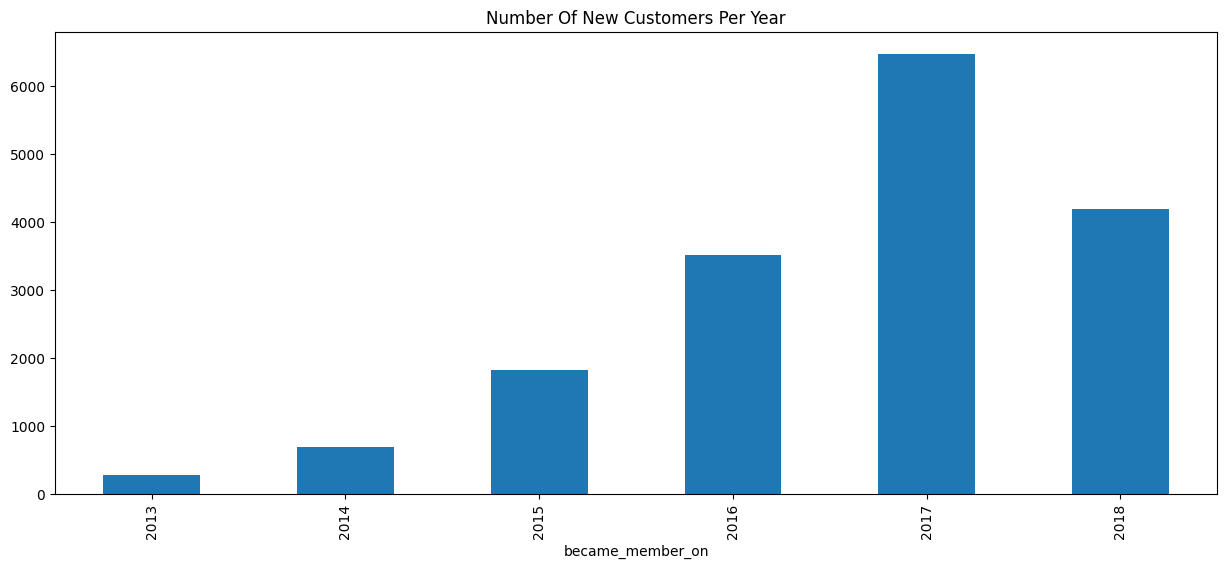

In [49]:
plt.title("Number Of New Customers Per Year")
pd.to_datetime(profile.became_member_on, format='%Y%m%d').dt.year.value_counts().sort_index().plot(kind='bar')
plt.show()

The customer base of the reward program grew over time.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\107704771.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  pd.to_datetime(profile.became_member_on, format='%Y%m%d').value_counts().resample('1ME').sum().sort_index().plot(kind='line')


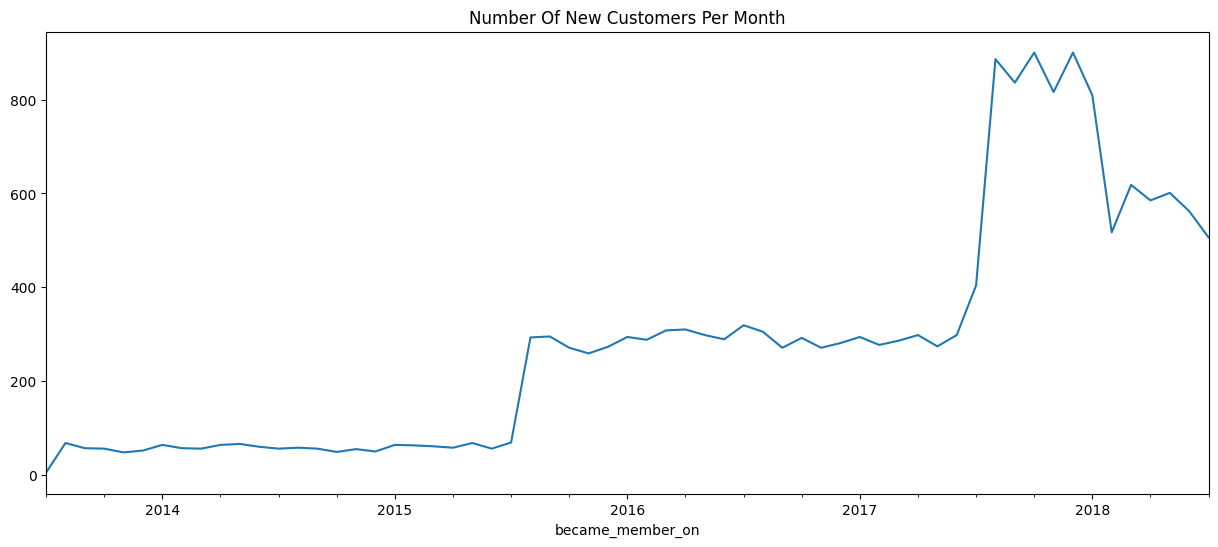

In [97]:
plt.title("Number Of New Customers Per Month")
pd.to_datetime(profile.became_member_on, format='%Y%m%d').value_counts().resample('1ME').sum().sort_index().plot(kind='line')
plt.show()

The strongest customer increase has been seen in the second half of 2017.

## Transactions

**transcript.json**
* event (str) - record description (ie transaction, offer received, offer viewed, etc.)
* person (str) - customer id
* time (int) - time in hours since start of test. The data begins at time t=0
* value - (dict of strings) - either an offer id or transaction amount depending on the record

In [64]:
transcript.head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [65]:
transcript.shape

(306534, 4)

In [66]:
transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   person  306534 non-null  str   
 1   event   306534 non-null  str   
 2   value   306534 non-null  object
 3   time    306534 non-null  int64 
dtypes: int64(1), object(1), str(2)
memory usage: 9.4+ MB


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\80765707.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  transcript.event.value_counts().plot(kind='bar')


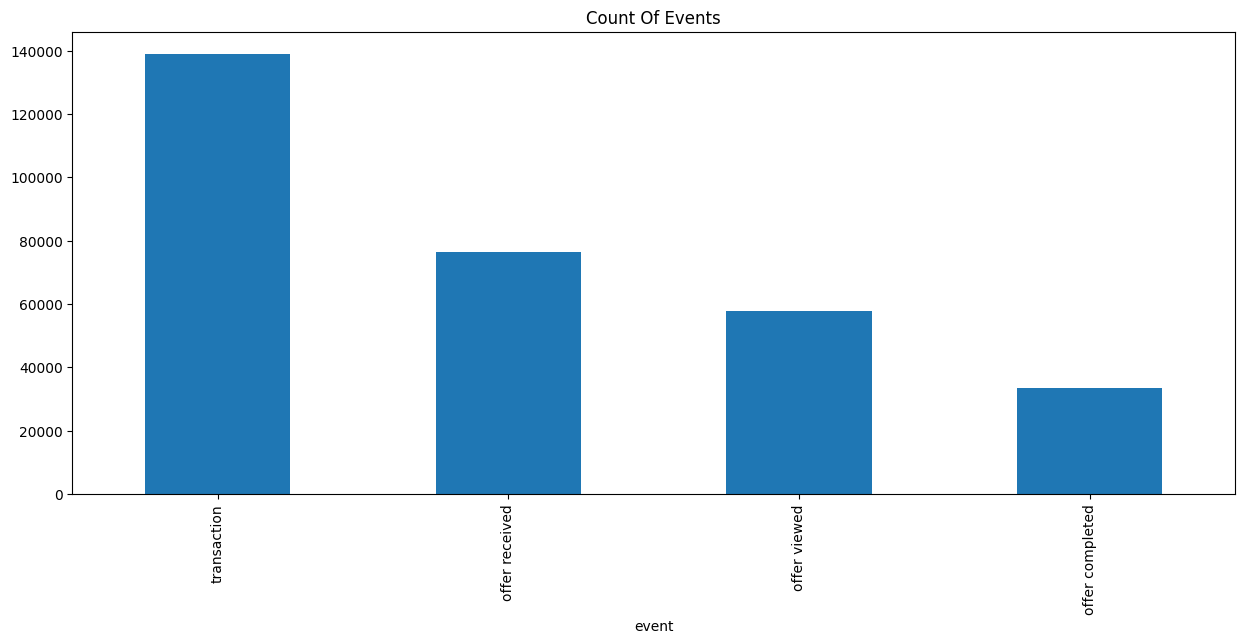

In [67]:
plt.title("Count Of Events")
transcript.event.value_counts().plot(kind='bar')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\3362419539.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  (transcript.time/24).value_counts().sort_index().plot()


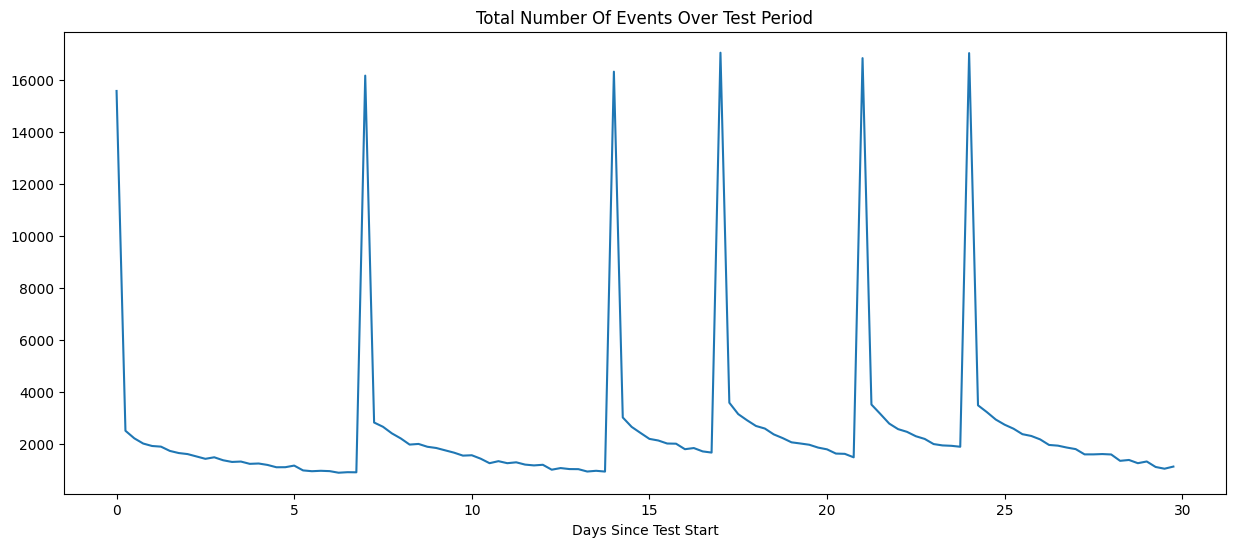

In [68]:
plt.title("Total Number Of Events Over Test Period")
(transcript.time/24).value_counts().sort_index().plot()
plt.xlabel("Days Since Test Start")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\2157901137.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  (transcript[transcript.event==event].time/24).value_counts().sort_index().plot(label=event)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\2157901137.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  (transcript[transcript.event==event].time/24).value_counts().sort_index().plot(label=event)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\2157901137.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is 

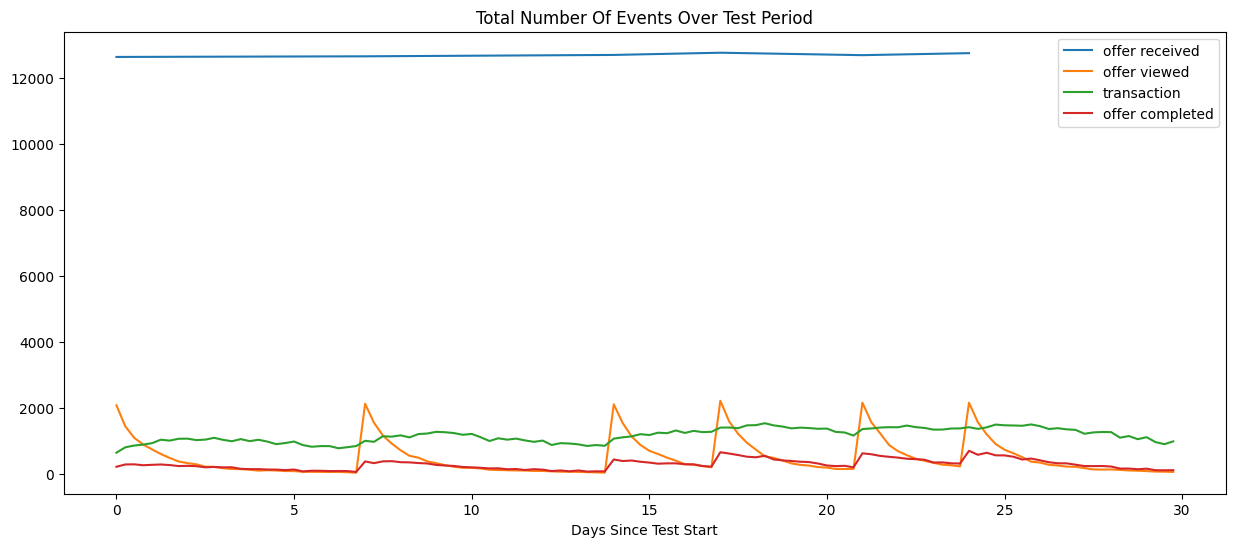

In [69]:
plt.title("Total Number Of Events Over Test Period")
for event in transcript.event.unique():
    (transcript[transcript.event==event].time/24).value_counts().sort_index().plot(label=event)
plt.xlabel("Days Since Test Start")
plt.legend()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\739794062.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  transcript.loc[transcript.event=='offer received', 'value'].map(lambda x: x.get('offer id')).value_counts().plot(kind='bar')


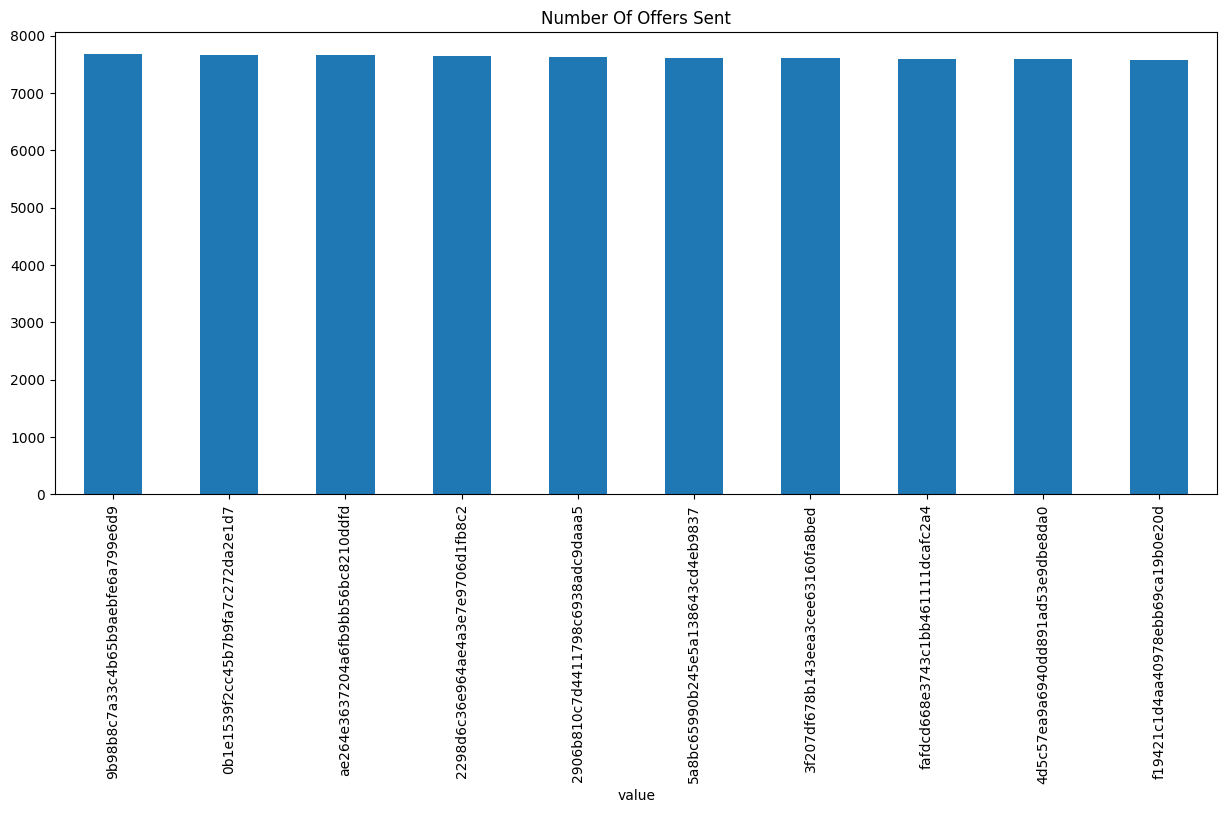

In [70]:
plt.title("Number Of Offers Sent")
transcript.loc[transcript.event=='offer received', 'value'].map(lambda x: x.get('offer id')).value_counts().plot(kind='bar')
plt.show()

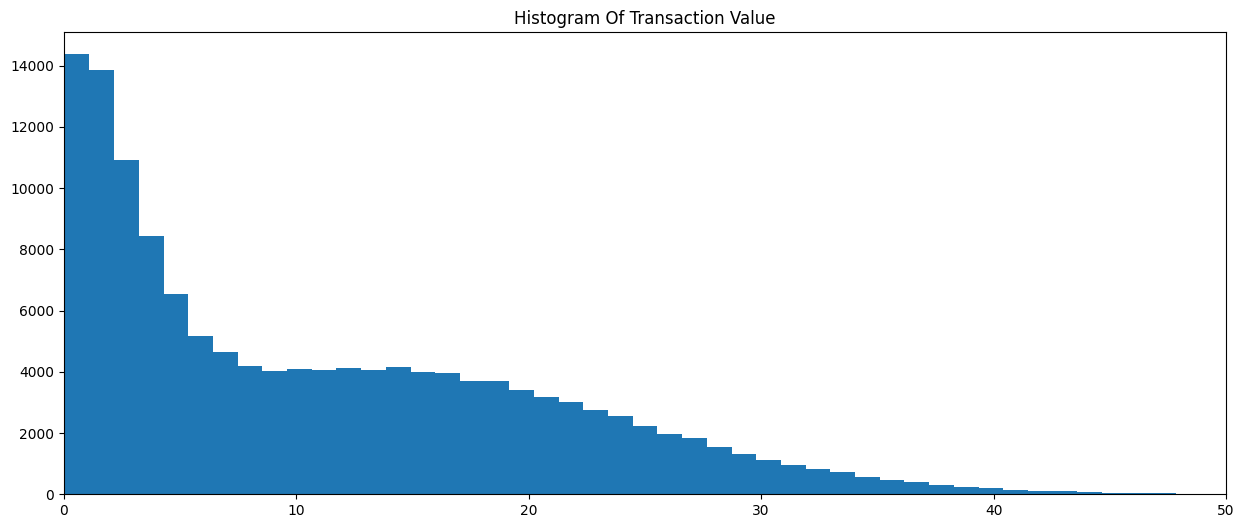

In [71]:
plt.title("Histogram Of Transaction Value")
transcript.loc[transcript.event=='transaction', 'value'].map(lambda x: x.get('amount')).hist(bins=1000, grid=False)
plt.xlim([0, 50])
plt.show()

In [72]:
transcript[transcript.person=='78afa995795e4d85b5d9ceeca43f5fef']

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
15561,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},6
47582,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.89},132
47583,78afa995795e4d85b5d9ceeca43f5fef,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,132
49502,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 17.78},144
53176,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},168
85291,78afa995795e4d85b5d9ceeca43f5fef,offer viewed,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},216
87134,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 19.67},222
92104,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 29.72},240
141566,78afa995795e4d85b5d9ceeca43f5fef,transaction,{'amount': 23.93},378


# Data Processing

In [93]:
# Create target variable for each person-offer combination
offer_events = ['offer received', 'offer viewed', 'offer completed']
offers_df = transcript[transcript.event.isin(offer_events)].copy()
offers_df['offer'] = transcript.value.map(lambda x: x.get('offer id') if x.get('offer id') is not None else x.get('offer_id')) 
offers_df = offers_df[['person', 'offer', 'event']]
offers_df = (
    pd.get_dummies(offers_df, columns=['event'], prefix_sep="", prefix="") # one hot encoding of event type
    .groupby(['person', 'offer'], as_index=False).max() # check occurence of events for each person-offer combination
    .rename(columns = lambda x: x.replace(' ', '_'))
)[['person', 'offer', 'offer_viewed', 'offer_completed']]

offers_df.head()

,person,offer,offer_viewed,offer_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,True


In [94]:
# Merge person and offer data
offers_df = offers_df.merge(profile, 'left', left_on='person', right_on='id').drop('id', axis=1)
offers_df = offers_df.merge(portfolio, 'left', left_on='offer', right_on='id').drop('id', axis=1)

# Drop informational offers
offers_df = offers_df[offers_df.offer_type!='informational']

# Count days since registration at the beginning at the test
# We approximate the start date of the test with the maximum registration date in the customer
# base, since the actual date is unknown
offers_df['days_since_registration'] = (
    pd.to_datetime(np.max(offers_df.became_member_on), format='%Y%m%d') 
    - pd.to_datetime(offers_df.became_member_on, format='%Y%m%d')
).dt.days
offers_df.drop('became_member_on', axis=1, inplace=True)

# One hot encode the channel column
channels = offers_df.channels.explode().unique()
for channel in channels:
    offers_df[channel] = offers_df.channels.map(lambda x: channel in x).astype(int)
offers_df.drop('channels', axis=1, inplace=True)

# Set null values in age column
offers_df['age'] = np.where(offers_df['age']==118, np.nan, offers_df['age'])

offers_df.head()

,person,offer,offer_viewed,offer_completed,gender,age,income,reward,difficulty,duration,offer_type,days_since_registration,web,email,mobile,social
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,False,True,M,33.0,72000.0,2,10,7,discount,461,1,1,1,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,True,M,33.0,72000.0,5,5,5,bogo,461,1,1,1,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,True,M,33.0,72000.0,2,10,10,discount,461,1,1,1,1
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,True,False,NaN,NaN,NaN,5,5,5,bogo,92,1,1,1,1
6,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,True,True,O,40.0,57000.0,5,20,10,discount,198,1,1,0,0


# Data Exploration

## View Rate Of Offers 

In [75]:
offers_df.offer_viewed.mean()

np.float64(0.7864999901257973)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\923480820.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby('offer_type').offer_viewed.mean().sort_values(ascending=False).plot(kind='bar')


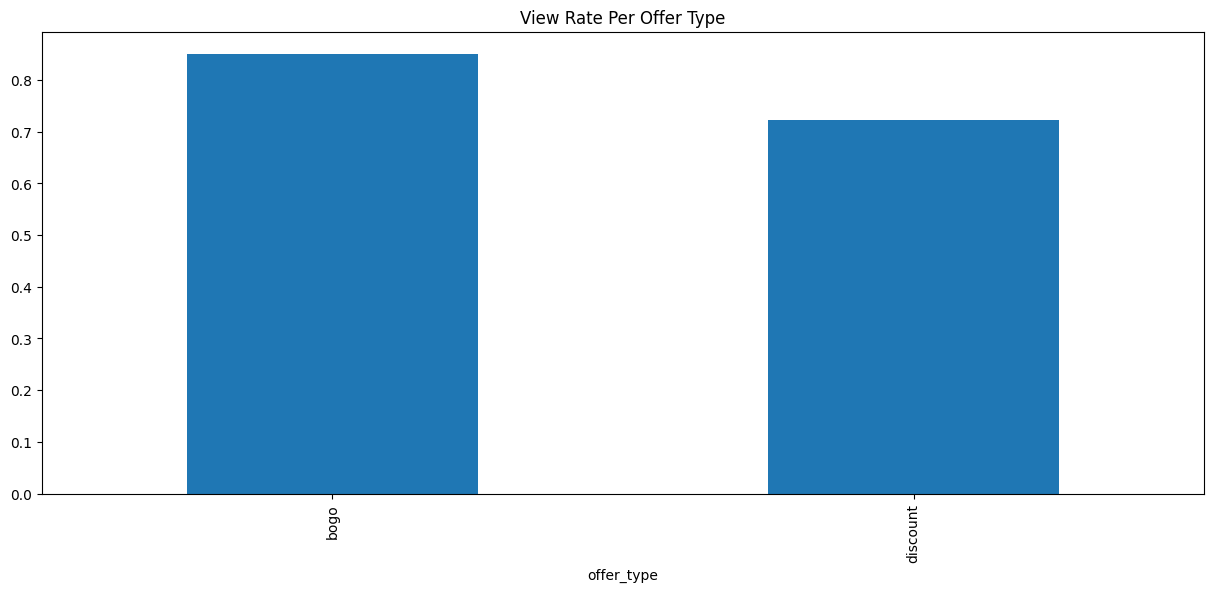

In [76]:
plt.title("View Rate Per Offer Type")
offers_df.groupby('offer_type').offer_viewed.mean().sort_values(ascending=False).plot(kind='bar')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\1182871389.py:10: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  channel_views.sort_index(key=lambda x: x.str.len()).plot(kind='bar')


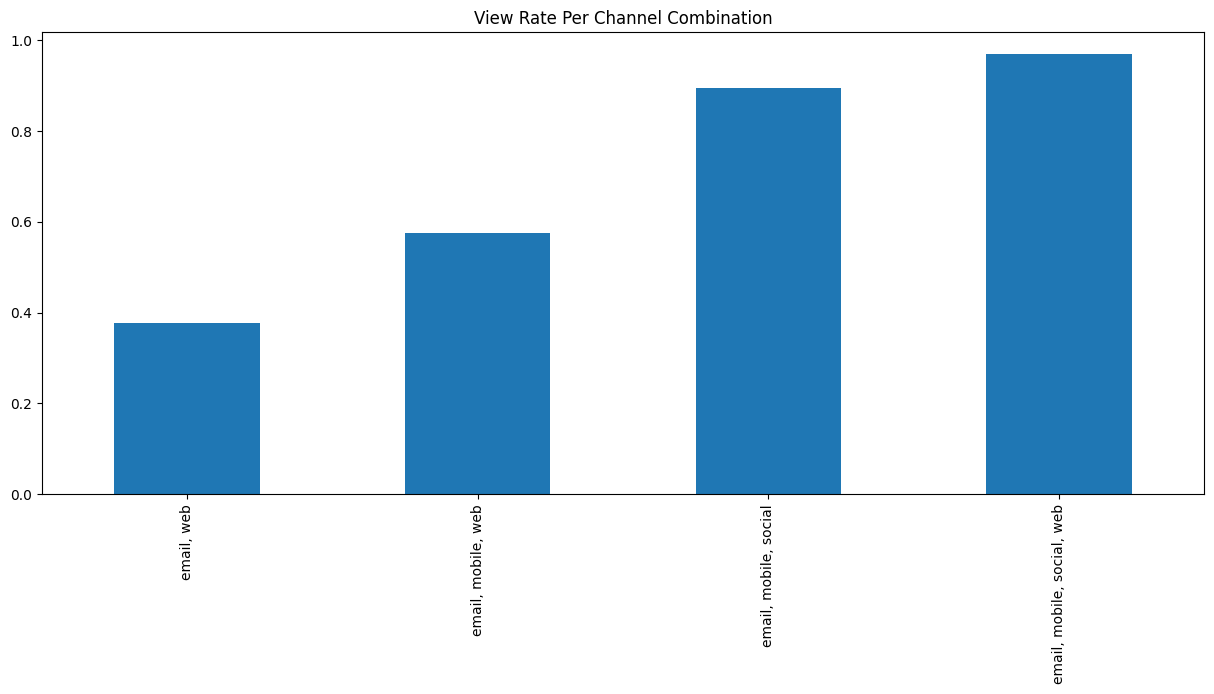

In [77]:
plt.title("View Rate Per Channel Combination")
channel_views = offers_df.groupby(['web', 'email', 'mobile', 'social']).offer_viewed.mean()
channel_views.index = channel_views.index.map(
    lambda x: ", ".join(
        sorted(
            [channel_views.index.names[i] for i in range(len(channel_views.index.names)) if x[i]]
        )
    )
)
channel_views.sort_index(key=lambda x: x.str.len()).plot(kind='bar')
plt.show()

In [95]:
# Remove offers that have not been seen
offers_df = offers_df[offers_df.offer_viewed==1].drop('offer_viewed', axis=1)

## Overview Of Columns

In [79]:
offers_df.shape

(39826, 15)

In [80]:
offers_df.info()

<class 'pandas.DataFrame'>
Index: 39826 entries, 3 to 63287
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   person                   39826 non-null  str    
 1   offer                    39826 non-null  str    
 2   offer_completed          39826 non-null  bool   
 3   gender                   34451 non-null  str    
 4   age                      34451 non-null  float64
 5   income                   34451 non-null  float64
 6   reward                   39826 non-null  int64  
 7   difficulty               39826 non-null  int64  
 8   duration                 39826 non-null  int64  
 9   offer_type               39826 non-null  str    
 10  days_since_registration  39826 non-null  int64  
 11  web                      39826 non-null  int64  
 12  email                    39826 non-null  int64  
 13  mobile                   39826 non-null  int64  
 14  social                   39826 non-nul

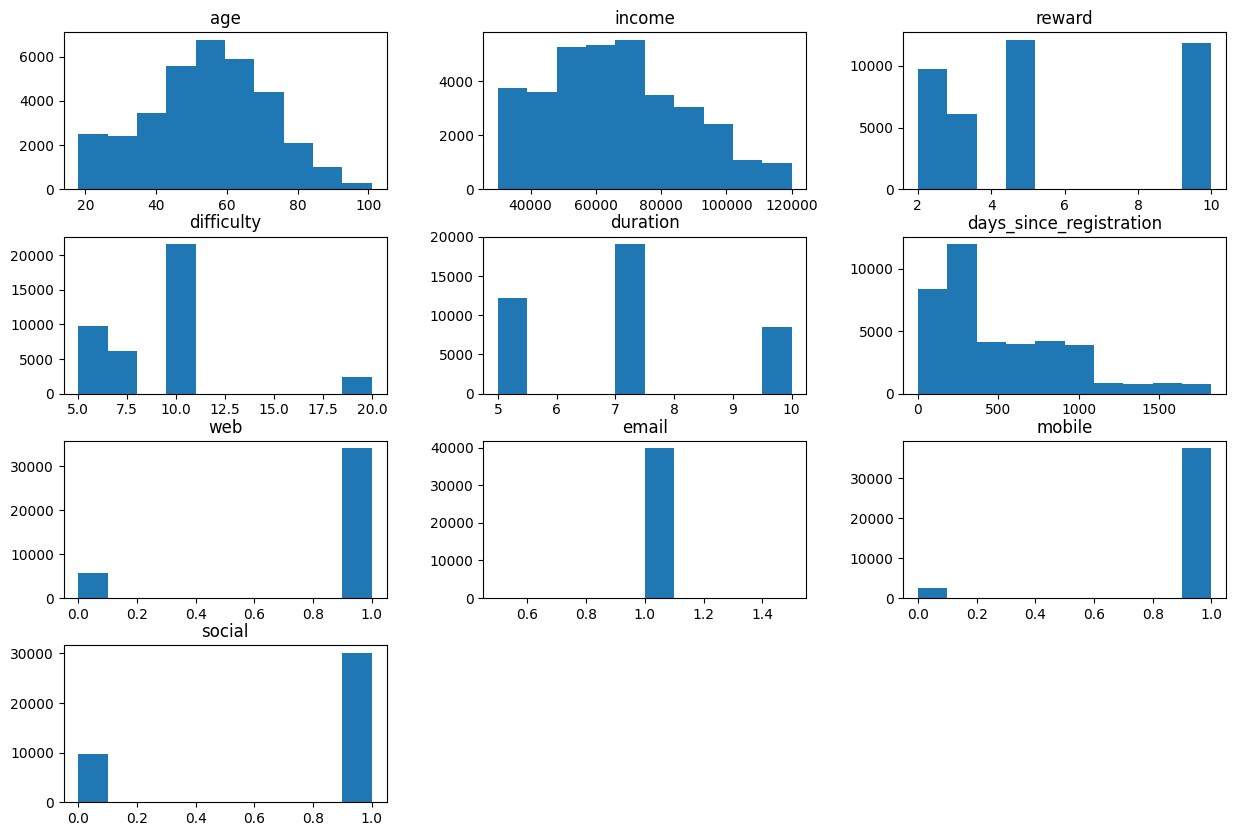

In [81]:
offers_df.hist(figsize=(15, 10), grid=False)
plt.show()

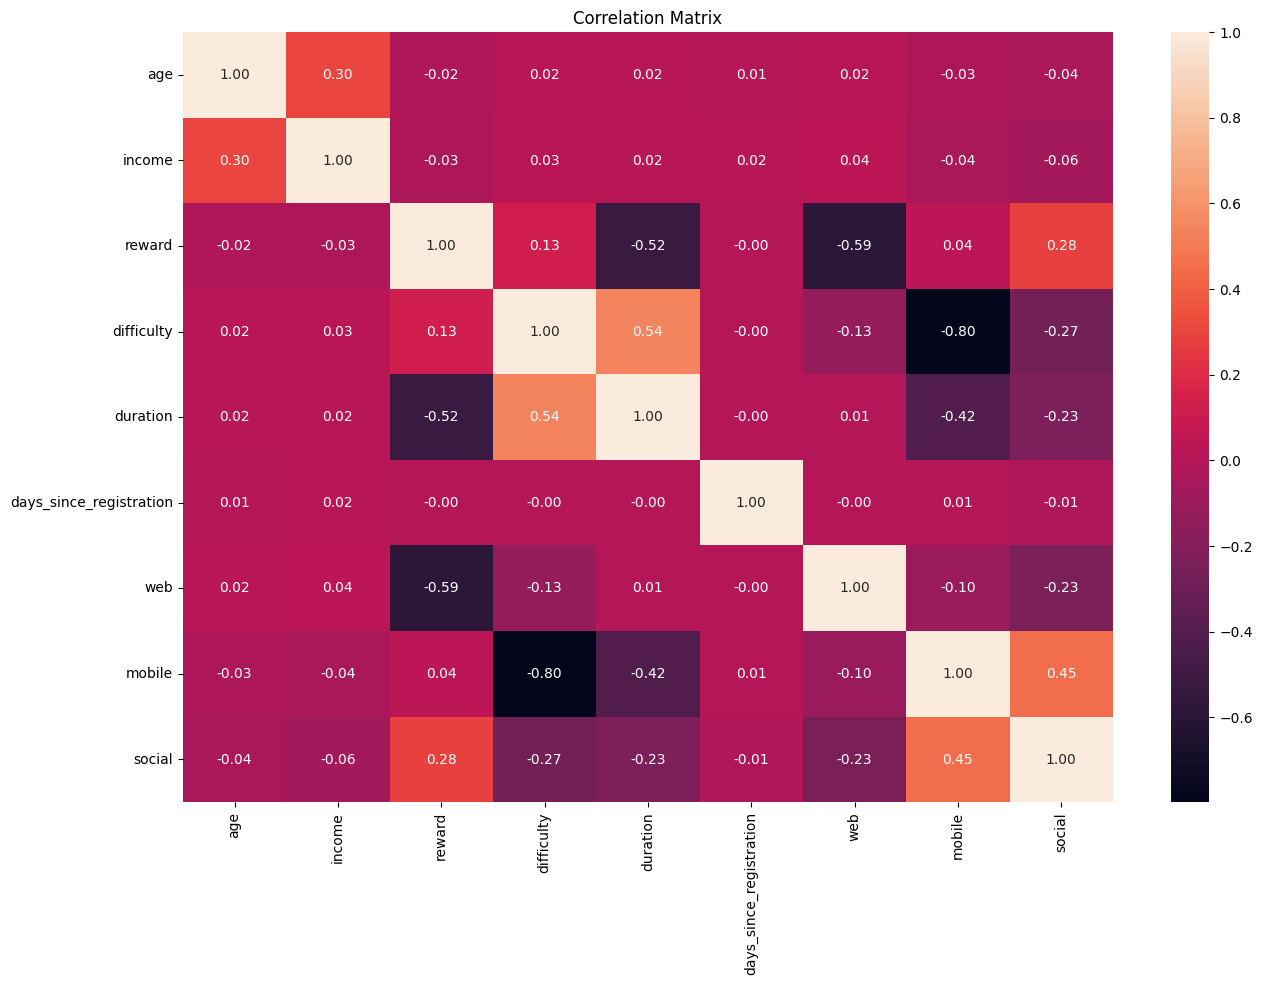

In [82]:
plt.figure(figsize=(15, 10))
plt.title("Correlation Matrix")
corr_df = offers_df.drop(columns=['email'], errors='ignore').select_dtypes(include=[np.number])
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f')
plt.show()

## Completion Rate Per Offer

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\2218060492.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby('offer').offer_completed.mean().sort_values().plot(kind='bar')


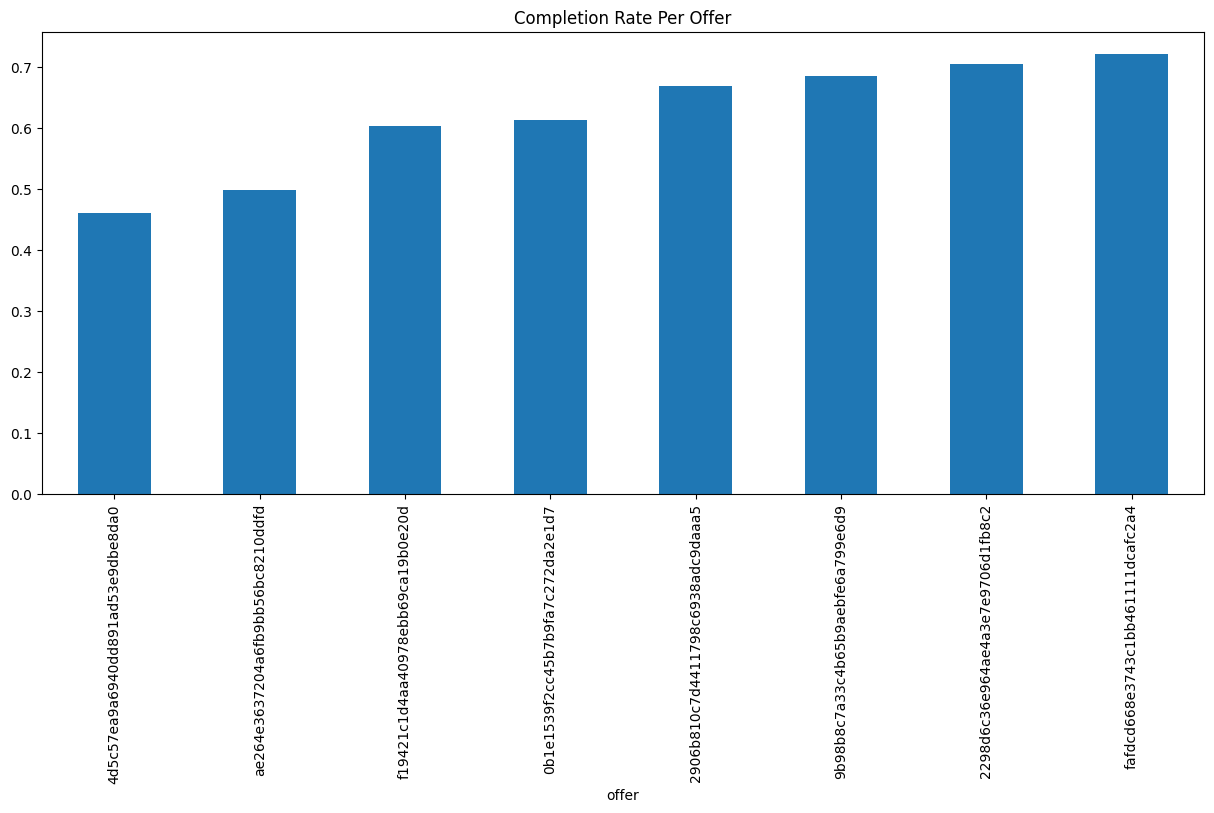

In [83]:
plt.title("Completion Rate Per Offer")
offers_df.groupby('offer').offer_completed.mean().sort_values().plot(kind='bar')
plt.show()

## Relationship Between Features And Target

#### Offer Related Features

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\1638008169.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby('offer_type').offer_completed.mean().sort_values().plot(kind='bar')


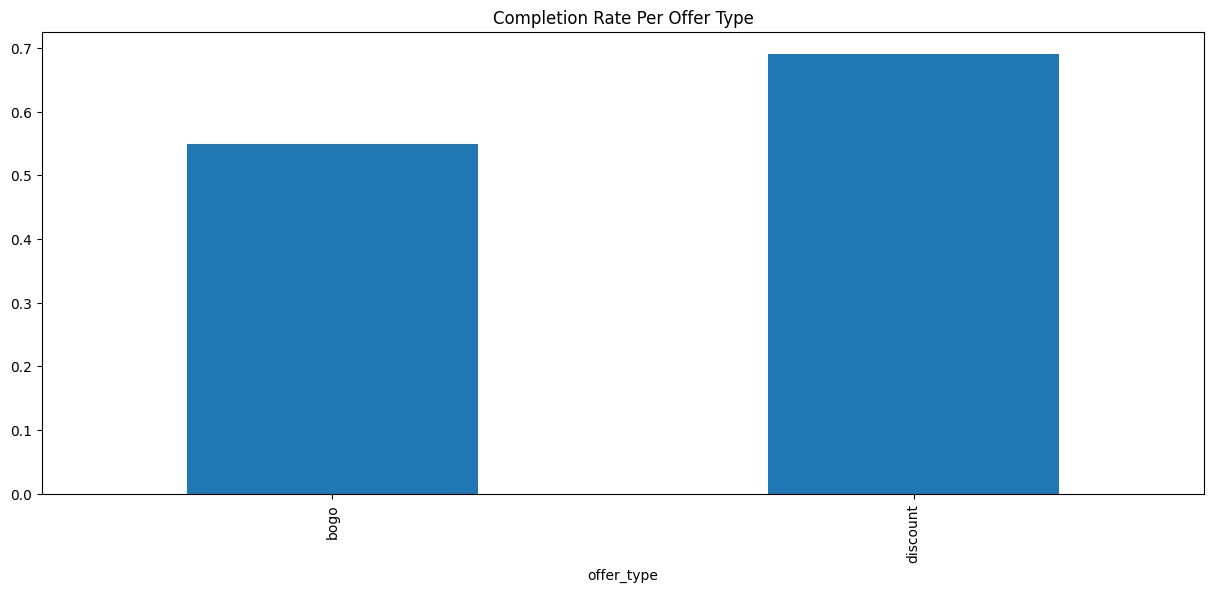

In [84]:
plt.title("Completion Rate Per Offer Type")
offers_df.groupby('offer_type').offer_completed.mean().sort_values().plot(kind='bar')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\38246071.py:6: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby(channel).offer_completed.mean().sort_index().plot(kind='bar', ax=ax)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\38246071.py:6: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby(channel).offer_completed.mean().sort_index().plot(kind='bar', ax=ax)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\38246071.py:6: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas

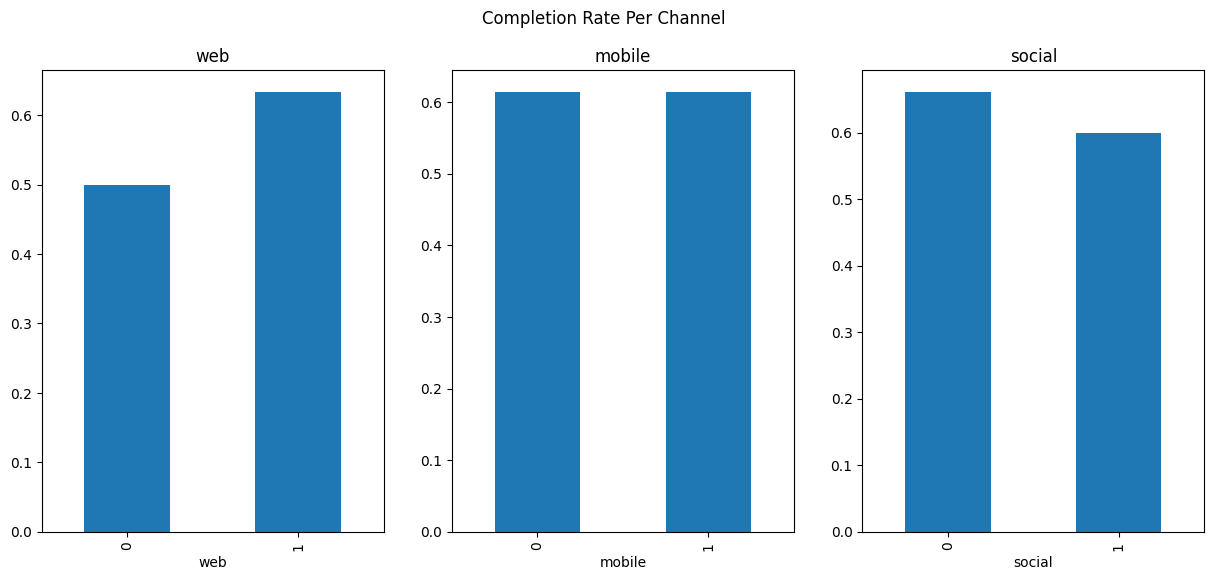

In [85]:
fig, axes = plt.subplots(1, 3)
fig.suptitle("Completion Rate Per Channel")
channels = ['web', 'mobile', 'social']
for ax, channel in zip(axes, channels):
    ax.set_title(channel)
    offers_df.groupby(channel).offer_completed.mean().sort_index().plot(kind='bar', ax=ax)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\2635075052.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby('difficulty').offer_completed.mean().sort_index().plot(kind='bar')


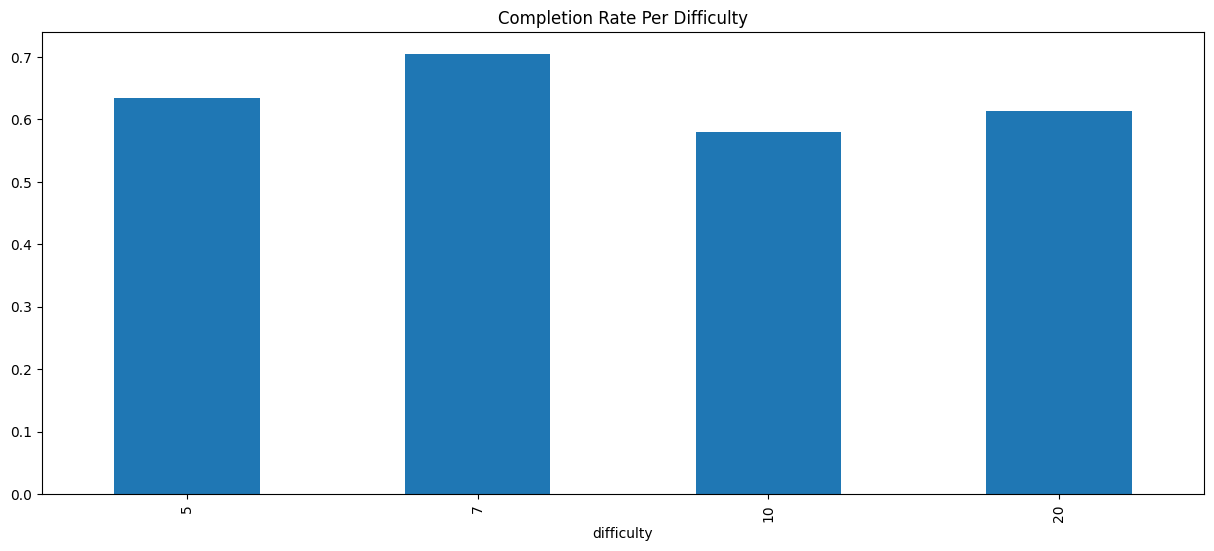

In [86]:
plt.title("Completion Rate Per Difficulty")
offers_df.groupby('difficulty').offer_completed.mean().sort_index().plot(kind='bar')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\615365485.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby('reward').offer_completed.mean().sort_index().plot(kind='bar')


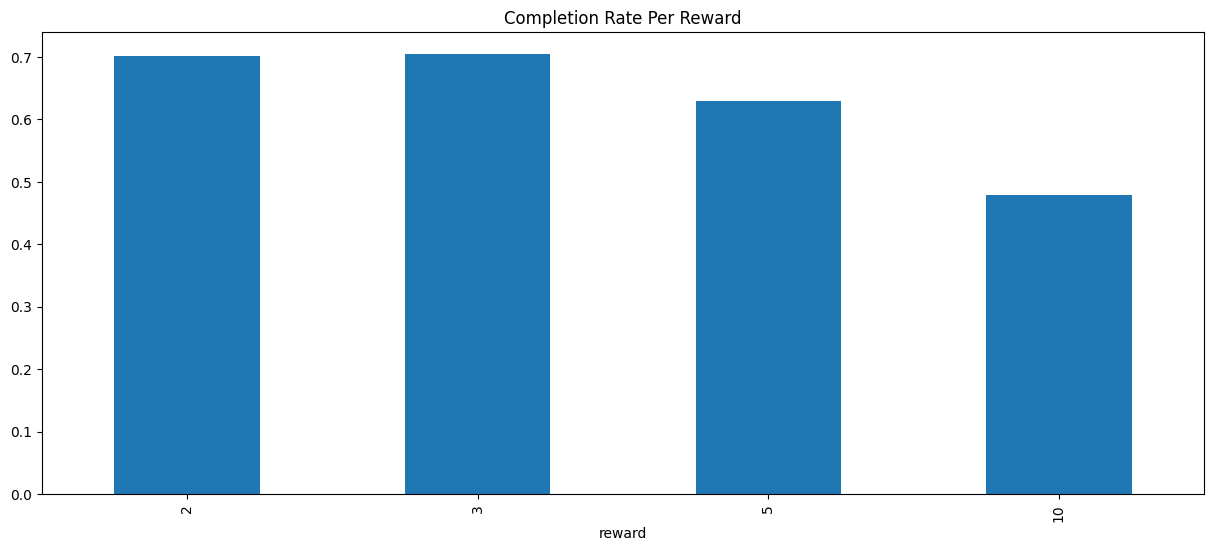

In [87]:
plt.title("Completion Rate Per Reward")
offers_df.groupby('reward').offer_completed.mean().sort_index().plot(kind='bar')
plt.show()

#### Customer-Related Features

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\3145125989.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby('gender').offer_completed.mean().sort_index().plot(kind='bar')


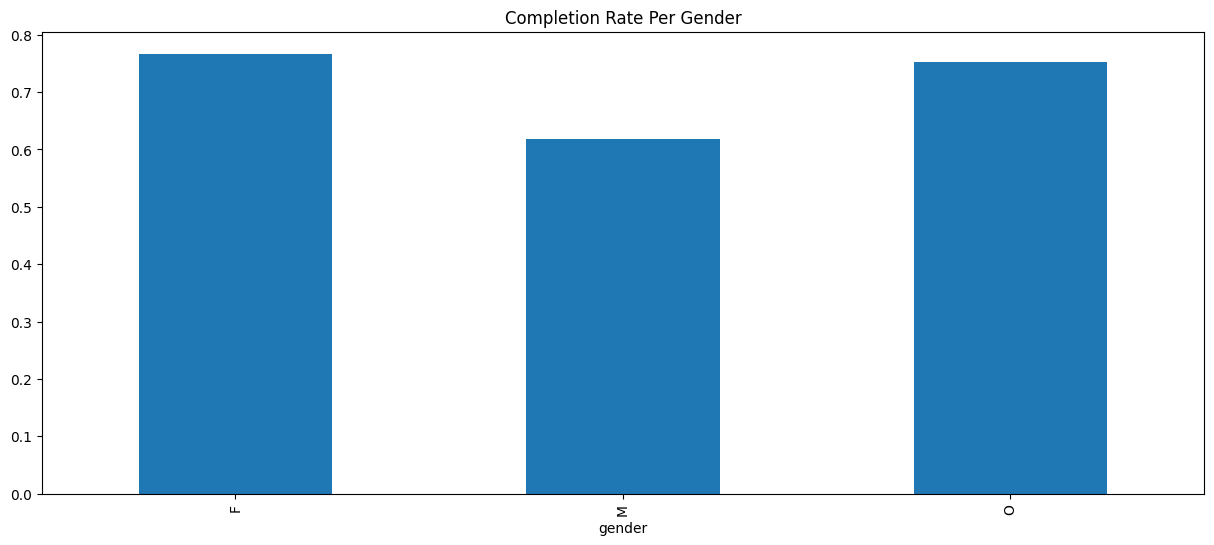

In [88]:
plt.title("Completion Rate Per Gender")
offers_df.groupby('gender').offer_completed.mean().sort_index().plot(kind='bar')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\836936665.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby(age_cuts).offer_completed.mean().sort_index().plot(kind='bar')


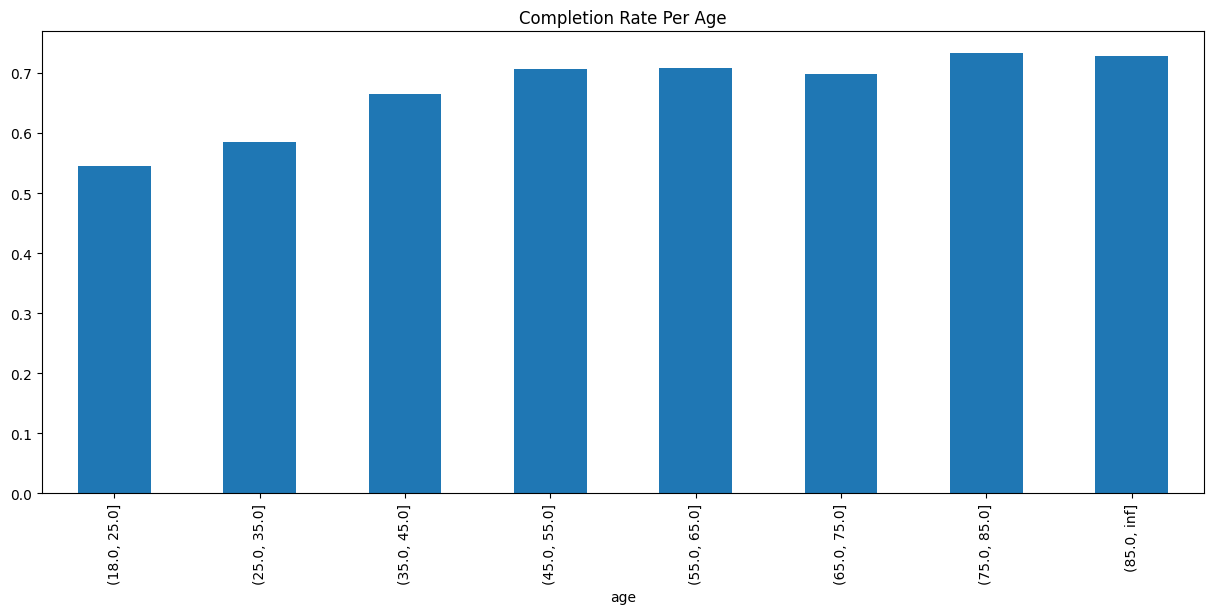

In [98]:
plt.title("Completion Rate Per Age")
age_cuts = pd.cut(offers_df.age, [18, 25, 35, 45, 55, 65, 75, 85, np.inf])
offers_df.groupby(age_cuts).offer_completed.mean().sort_index().plot(kind='bar')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\1664427057.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby(income_cuts).offer_completed.mean().sort_index().plot(kind='bar')


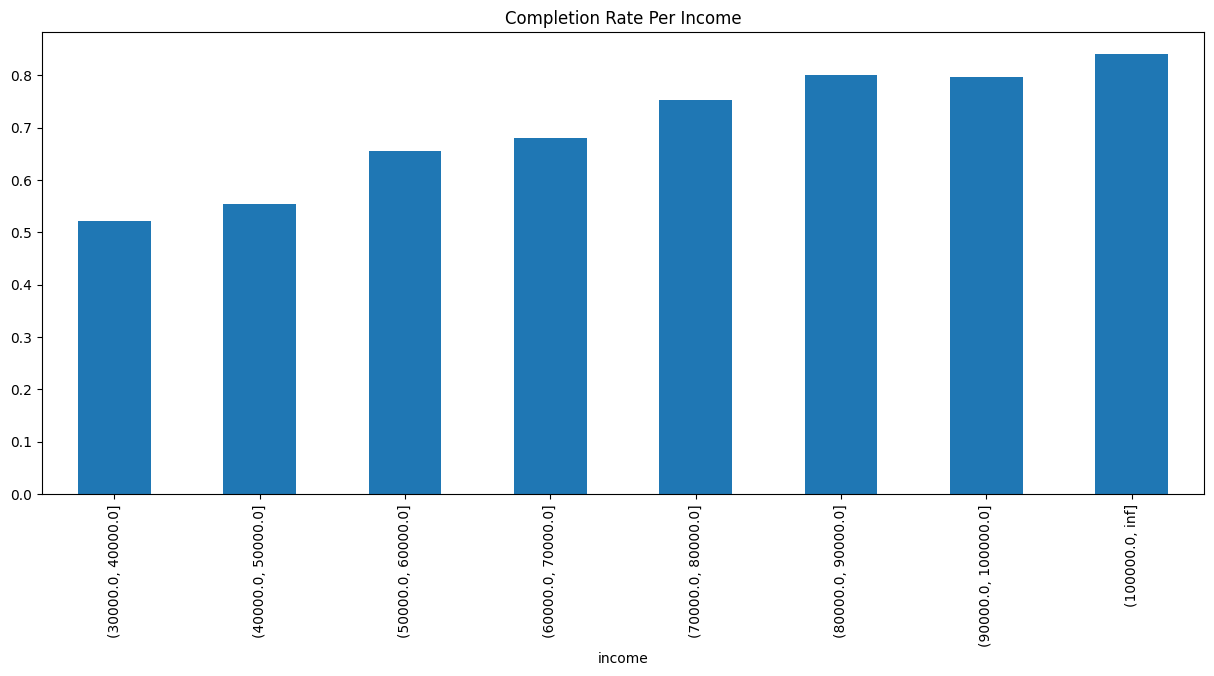

In [99]:
plt.title("Completion Rate Per Income")
income_cuts = pd.cut(offers_df.income, [30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000, np.inf])
offers_df.groupby(income_cuts).offer_completed.mean().sort_index().plot(kind='bar')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17548\829602106.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  offers_df.groupby(regr_cuts).offer_completed.mean().sort_index().plot(kind='bar')


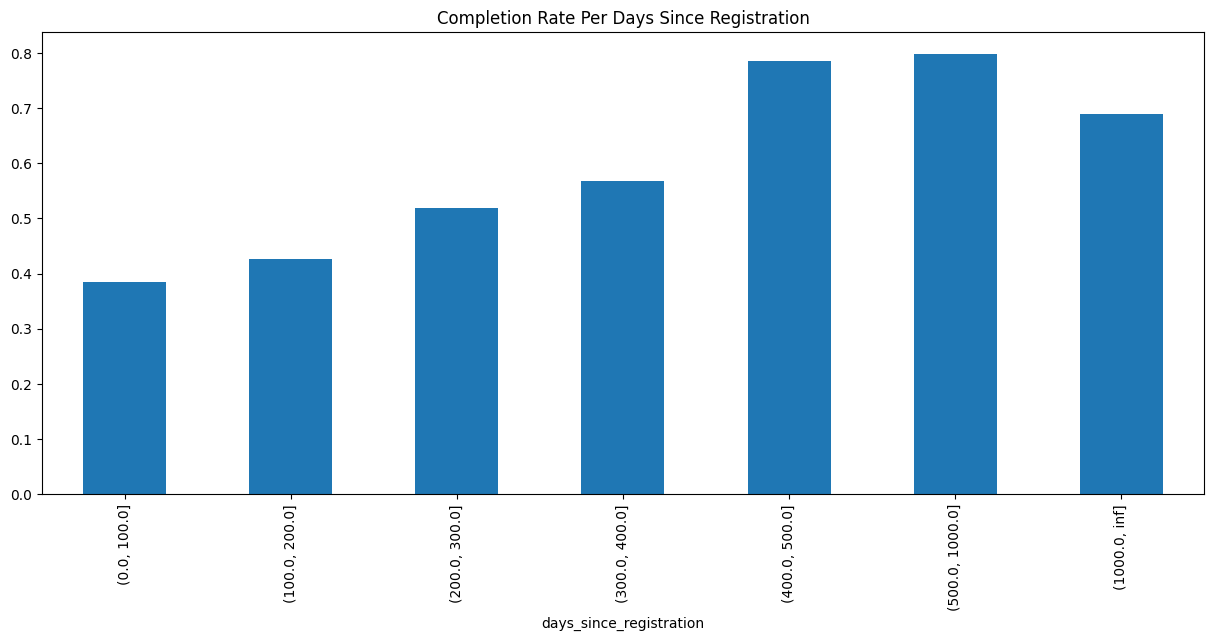

In [100]:
plt.title("Completion Rate Per Days Since Registration")
regr_cuts = pd.cut(offers_df.days_since_registration, [0, 100, 200, 300, 400, 500, 1000, np.inf])
offers_df.groupby(regr_cuts).offer_completed.mean().sort_index().plot(kind='bar')
plt.show()

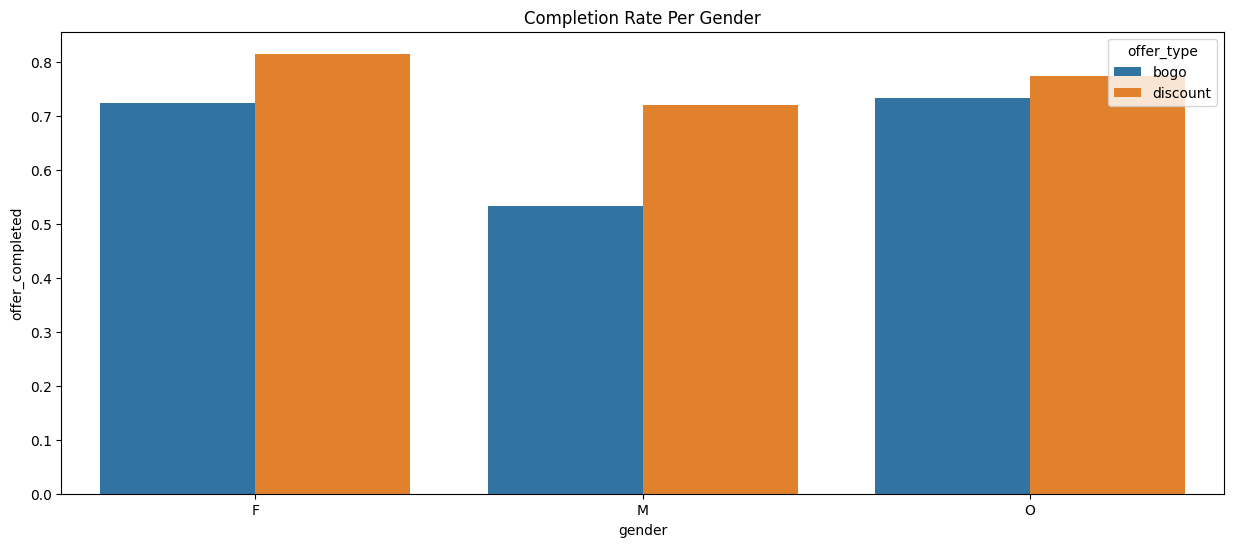

In [101]:
plt.title("Completion Rate Per Gender")
sns.barplot(
    x='gender', y='offer_completed', hue='offer_type', 
    data=offers_df.groupby(['gender', 'offer_type']).offer_completed.mean().to_frame().reset_index()
)
plt.show()

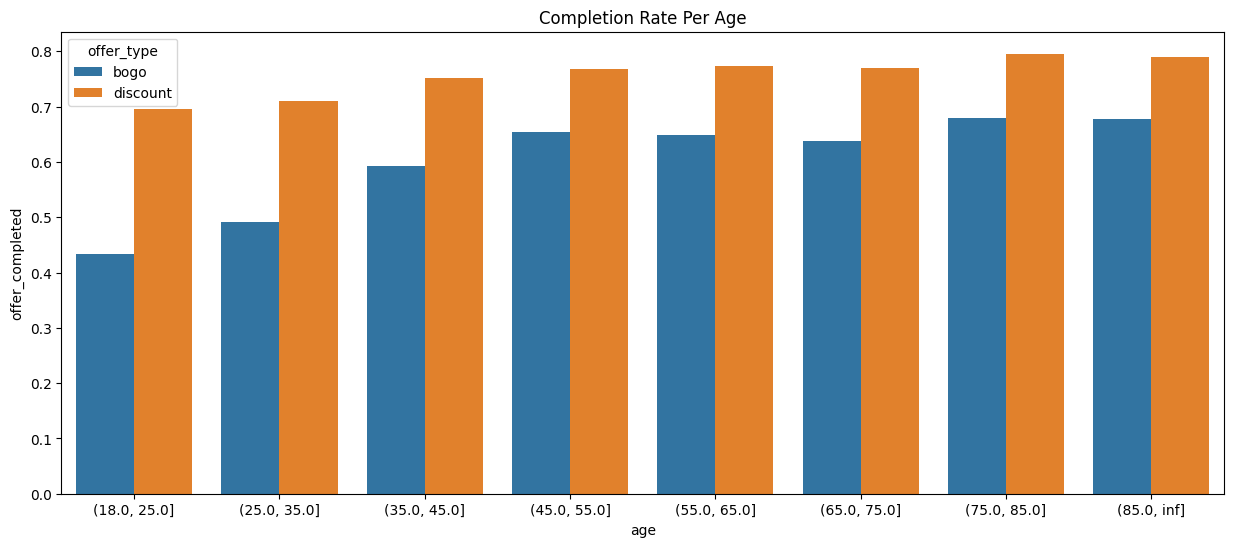

In [102]:
plt.title("Completion Rate Per Age")
age_cuts = pd.cut(offers_df.age, [18, 25, 35, 45, 55, 65, 75, 85, np.inf])
sns.barplot(
    x='age', y='offer_completed', hue='offer_type', 
    data=offers_df.groupby([age_cuts, offers_df.offer_type]).offer_completed.mean().to_frame().reset_index()
)
plt.show()

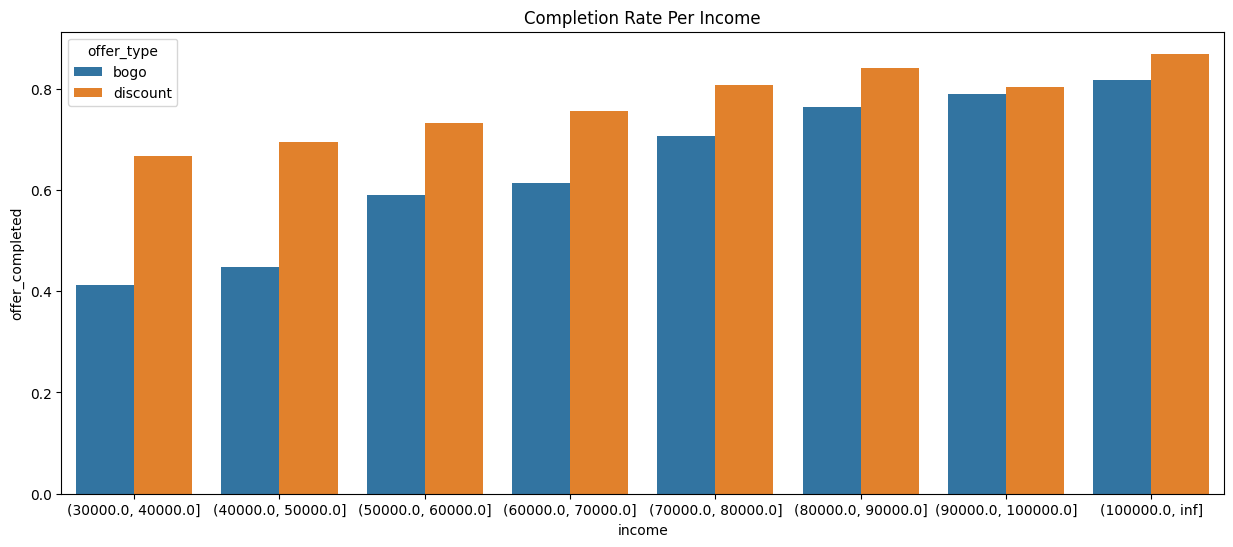

In [103]:
plt.title("Completion Rate Per Income")
income_cuts = pd.cut(offers_df.income, [30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000, np.inf])
sns.barplot(
    x='income', y='offer_completed', hue='offer_type', 
    data=offers_df.groupby([income_cuts, offers_df.offer_type]).offer_completed.mean().to_frame().reset_index()
)
plt.show()

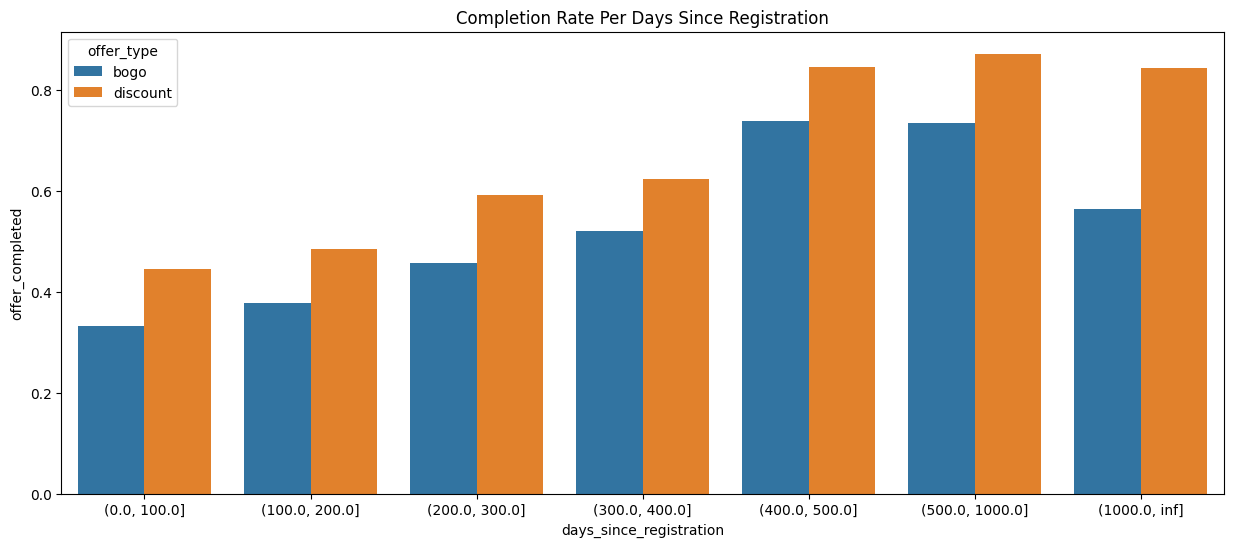

In [104]:
plt.title("Completion Rate Per Days Since Registration")
regr_cuts = pd.cut(offers_df.days_since_registration, [0, 100, 200, 300, 400, 500, 1000, np.inf])
sns.barplot(
    x='days_since_registration', y='offer_completed', hue='offer_type', 
    data=offers_df.groupby([regr_cuts, offers_df.offer_type]).offer_completed.mean().to_frame().reset_index()
)
plt.show()

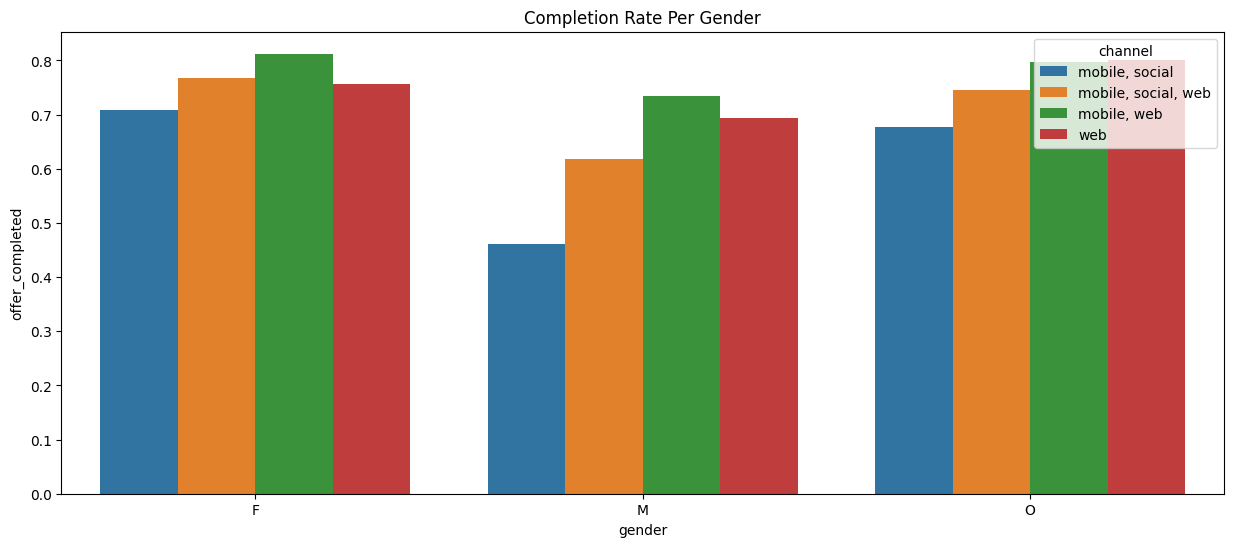

In [107]:
plt.title("Completion Rate Per Gender")
cols = ['web', 'mobile', 'social']
channel_labels = offers_df[cols].apply(
    lambda row: ", ".join(sorted([cols[i] for i in range(len(cols)) if row.iloc[i]])),
    axis=1
).rename('channel')
sns.barplot(
    x='gender', y='offer_completed', hue='channel', 
    data=offers_df.groupby([offers_df.gender, channel_labels]).offer_completed.mean().to_frame().reset_index()
 )
plt.show()

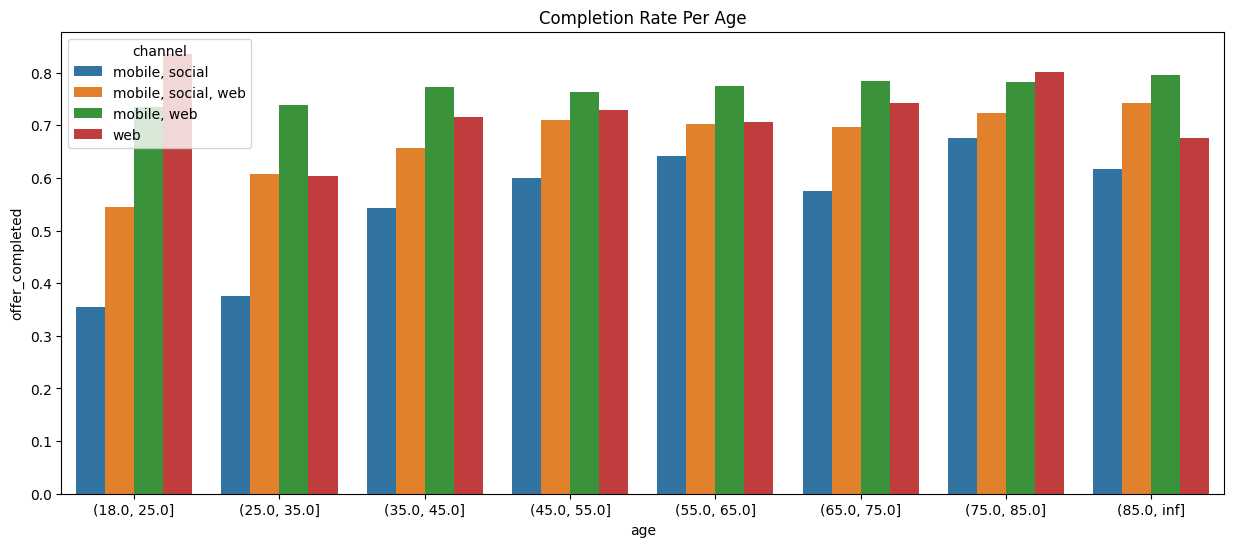

In [108]:
plt.title("Completion Rate Per Age")
cols = ['web', 'mobile', 'social']
channel_labels = offers_df[cols].apply(
    lambda row: ", ".join(sorted([cols[i] for i in range(len(cols)) if row.iloc[i]])),
    axis=1
).rename('channel')
sns.barplot(
    x='age', y='offer_completed', hue='channel', 
    data=offers_df.groupby([age_cuts, channel_labels]).offer_completed.mean().to_frame().reset_index()
 )
plt.show()

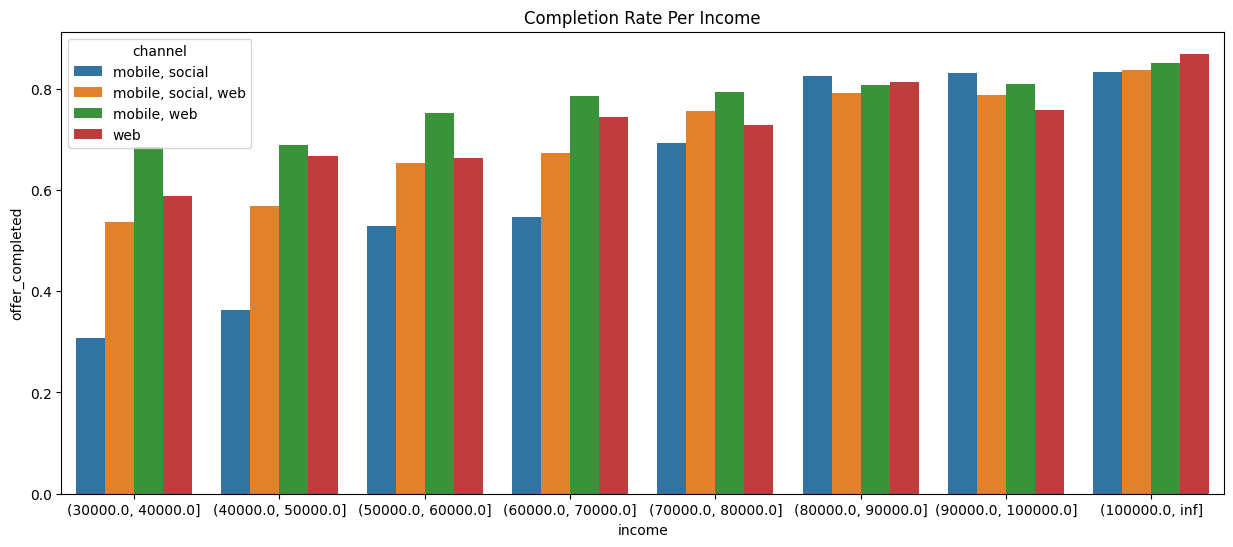

In [109]:
plt.title("Completion Rate Per Income")
cols = ['web', 'mobile', 'social']
channel_labels = offers_df[cols].apply(
    lambda row: ", ".join(sorted([cols[i] for i in range(len(cols)) if row.iloc[i]])),
    axis=1
).rename('channel')
sns.barplot(
    x='income', y='offer_completed', hue='channel', 
    data=offers_df.groupby([income_cuts, channel_labels]).offer_completed.mean().to_frame().reset_index()
 )
plt.show()

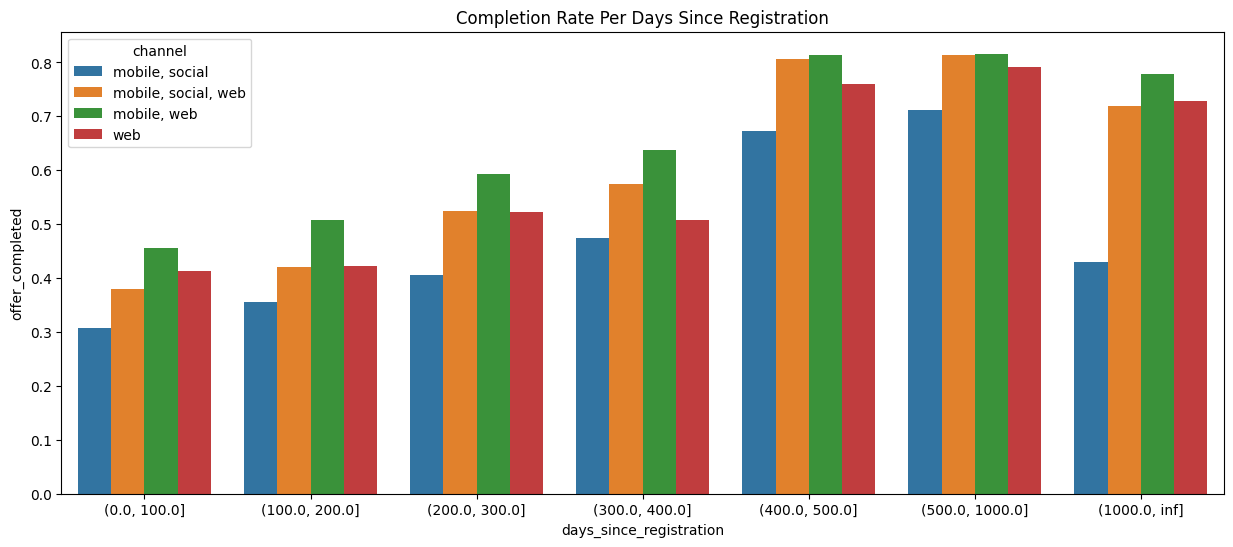

In [110]:
plt.title("Completion Rate Per Days Since Registration")
cols = ['web', 'mobile', 'social']
channel_labels = offers_df[cols].apply(
    lambda row: ", ".join(sorted([cols[i] for i in range(len(cols)) if row.iloc[i]])),
    axis=1
).rename('channel')
sns.barplot(
    x='days_since_registration', y='offer_completed', hue='channel', 
    data=offers_df.groupby([regr_cuts, channel_labels]).offer_completed.mean().to_frame().reset_index()
 )
plt.show()

## Save Dataset

In [111]:
offers_df.head()

,person,offer,offer_completed,gender,age,income,reward,difficulty,duration,offer_type,days_since_registration,web,email,mobile,social
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,M,33.0,72000.0,5,5,5,bogo,461,1,1,1,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,M,33.0,72000.0,2,10,10,discount,461,1,1,1,1
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,False,NaN,NaN,NaN,5,5,5,bogo,92,1,1,1,1
6,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,True,O,40.0,57000.0,5,20,10,discount,198,1,1,0,0
7,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,True,O,40.0,57000.0,3,7,7,discount,198,1,1,1,1


In [112]:
output_dir = DATA_DIR / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
pd.get_dummies(offers_df, columns=['gender', 'offer_type'], drop_first=True).to_csv(output_dir / 'preprocessed_data.csv', index=False)